In [14]:
"""
Morris Sensitivity Analysis
============================
Reads the sampling matrix and objective function values,
runs morris.analyze() for each species and the composite,
and produces mu*-sigma plots.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from SALib.analyze import morris as morris_analyze
from SALib.sample import morris as morris_sample

# ============================================================
# Configuration
# ============================================================
SENSITIVITY_PATH = Path("/Users/christiandewey/Code/dewey-etal_meanders/sensitivity/")
MORRIS_SAMPLES_CSV = SENSITIVITY_PATH / "morris_parameter_sets.csv"
OBJ_FUNC_CSV = SENSITIVITY_PATH / "objective_function_values.csv"
OUTPUT_DIR = SENSITIVITY_PATH / "analysis_results"
OUTPUT_DIR.mkdir(exist_ok=True)


In [15]:
# Problem definition (must match sampling exactly)
problem = {
    'num_vars': 16,
    'names': [
        'calcite_rate', 'fh_rmax', 'fh_k_donor', 'fh_SA',
        'gt_rmax', 'gt_k_donor', 'gt_SA', 'root_resp',
        'msr_rmax', 'msr_k_donor', 'msr_k_acceptor',
        'denit_rmax', 'denit_k_donor', 'denit_k_acceptor',
        'aero_rate', 'aero_k_o2',
    ],
    'bounds': [
        [np.log10(1.55e-07), np.log10(1.55e-05)],   # calcite_rate
        [np.log10(2.50e-07), np.log10(2.50e-06)],    # fh_rmax (tightened)
        [np.log10(1.00e-06), np.log10(1.00e-05)],    # fh_k_donor (tightened)
        [np.log10(1.08e+06), np.log10(1.08e+08)],    # fh_SA
        [np.log10(2.50e-08), np.log10(2.50e-06)],    # gt_rmax
        [np.log10(1.00e-07), np.log10(1.00e-05)],    # gt_k_donor
        [np.log10(2.83e+05), np.log10(2.83e+07)],    # gt_SA
        [np.log10(7.94e-14), np.log10(7.94e-12)],    # root_resp
        [np.log10(2.50e-08), np.log10(2.50e-06)],    # msr_rmax
        [np.log10(5.00e-07), np.log10(5.00e-05)],    # msr_k_donor
        [np.log10(1.00e-05), np.log10(1.00e-03)],    # msr_k_acceptor
        [np.log10(1.00e-07), np.log10(1.00e-05)],    # denit_rmax
        [np.log10(1.00e-06), np.log10(1.00e-04)],    # denit_k_donor
        [np.log10(1.00e-06), np.log10(1.00e-04)],    # denit_k_acceptor
        [np.log10(1.00e-10), np.log10(1.00e-08)],    # aero_rate
        [np.log10(1.00e-05), np.log10(1.00e-03)],    # aero_k_o2
    ],
    'num_levels': 4,
}

# Objective function columns to analyze
OBJ_COLUMNS = {
    'J_DIC':   'DIC',
    'J_Fe':    'Fe²⁺',
    'J_pH':    'pH',
    'J_Ca':    'Ca²⁺',
    'J_total': 'Composite',
}



In [16]:
# ============================================================
# Load data
# ============================================================
samples = pd.read_csv(MORRIS_SAMPLES_CSV, index_col='run_id')
obj_func = pd.read_csv(OBJ_FUNC_CSV, index_col='run_id')

# Only use the first 340 rows (20 trajectories)
n_runs = len(obj_func)
samples = samples.iloc[:n_runs]
X = np.log10(samples.values)

# Load sampling matrix in log space (as generated by SALib)
X = np.log10(samples.values)

print(f"Sample matrix shape: {X.shape}")
print(f"Objective function shape: {obj_func.shape}")



Sample matrix shape: (340, 16)
Objective function shape: (340, 6)


In [17]:
# ============================================================
# Handle failed runs — replace NaN with penalty value
# ============================================================
for col in OBJ_COLUMNS.keys():
    if col not in obj_func.columns:
        print(f"WARNING: {col} not found in objective function CSV")
        continue

    values = obj_func[col].values.astype(float)
    n_nan = np.isnan(values).sum()

    if n_nan > 0:
        penalty = np.nanmax(values) * 2.0
        values[np.isnan(values)] = penalty
        obj_func[col] = values
        print(f"{col}: replaced {n_nan} NaN values with penalty = {penalty:.4f}")
    else:
        print(f"{col}: no NaN values")



J_DIC: replaced 15 NaN values with penalty = 63.2178
J_Fe: replaced 15 NaN values with penalty = 1236.6840
J_pH: replaced 15 NaN values with penalty = 91.1256
J_Ca: replaced 15 NaN values with penalty = 35.4320
J_total: replaced 15 NaN values with penalty = 1424.9281


In [18]:
# ============================================================
# Run Morris analysis for each objective function
# ============================================================
results = {}

for col, label in OBJ_COLUMNS.items():
    if col not in obj_func.columns:
        continue

    Y = obj_func[col].values.astype(float)

    si = morris_analyze.analyze(
        problem,
        X,
        Y,
        num_levels=4,
        print_to_console=False,
    )

    results[col] = si

    # Compute range-normalized values
    # Multiply mu* and sigma by (range / max_range) to account for
    # parameters with different range widths
    param_ranges = np.array([b[1] - b[0] for b in problem['bounds']])
    max_range = param_ranges.max()
    norm_factors = max_range / param_ranges

    mu_star_norm = si['mu_star'] * norm_factors
    sigma_norm = si['sigma'] * norm_factors

    # Store results in a DataFrame
    si_df = pd.DataFrame({
        'parameter': problem['names'],
        'mu_star': si['mu_star'],
        'sigma': si['sigma'],
        'mu': si['mu'],
        'mu_star_conf': si['mu_star_conf'],
        'range_OOM': param_ranges,
        'mu_star_norm': mu_star_norm,
        'sigma_norm': sigma_norm,
    })
    si_df = si_df.sort_values('mu_star', ascending=False)

    # Save to CSV
    si_df.to_csv(OUTPUT_DIR / f"morris_{col}.csv", index=False)

    # Print raw results
    print(f"\n{'=' * 70}")
    print(f"MORRIS RESULTS (RAW): {label} ({col})")
    print(f"{'=' * 70}")
    print(f"{'Parameter':<22} {'μ*':>10} {'σ':>10} {'σ/μ*':>10} {'Range(OOM)':>11}")
    print("-" * 65)
    for _, row in si_df.iterrows():
        ratio = row['sigma'] / row['mu_star'] if row['mu_star'] > 0 else 0
        print(f"{row['parameter']:<22} {row['mu_star']:>10.4f} {row['sigma']:>10.4f} {ratio:>10.2f} {row['range_OOM']:>11.1f}")

    # Print range-normalized results
    si_df_norm = si_df.sort_values('mu_star_norm', ascending=False)
    print(f"\n{'=' * 70}")
    print(f"MORRIS RESULTS (RANGE-NORMALIZED): {label} ({col})")
    print(f"{'=' * 70}")
    print(f"{'Parameter':<22} {'μ*_norm':>10} {'σ_norm':>10} {'σ/μ*':>10} {'Range(OOM)':>11}")
    print("-" * 65)
    for _, row in si_df_norm.iterrows():
        ratio = row['sigma_norm'] / row['mu_star_norm'] if row['mu_star_norm'] > 0 else 0
        print(f"{row['parameter']:<22} {row['mu_star_norm']:>10.4f} {row['sigma_norm']:>10.4f} {ratio:>10.2f} {row['range_OOM']:>11.1f}")


MORRIS RESULTS (RAW): DIC (J_DIC)
Parameter                      μ*          σ       σ/μ*  Range(OOM)
-----------------------------------------------------------------
root_resp                 23.9054    31.7234       1.33         2.0
aero_k_o2                 11.4134    30.6345       2.68         2.0
aero_rate                  4.9842    15.4592       3.10         2.0
msr_k_donor                4.8892    20.8649       4.27         2.0
denit_rmax                 4.4943    20.0902       4.47         2.0
denit_k_acceptor           4.4851    20.0498       4.47         2.0
fh_rmax                    0.8692     1.3269       1.53         1.0
fh_k_donor                 0.8057     1.5572       1.93         1.0
msr_rmax                   0.3885     0.7510       1.93         2.0
msr_k_acceptor             0.1448     0.2944       2.03         2.0
gt_rmax                    0.0860     0.1658       1.93         2.0
gt_k_donor                 0.0473     0.0826       1.75         2.0
calcite_rate   

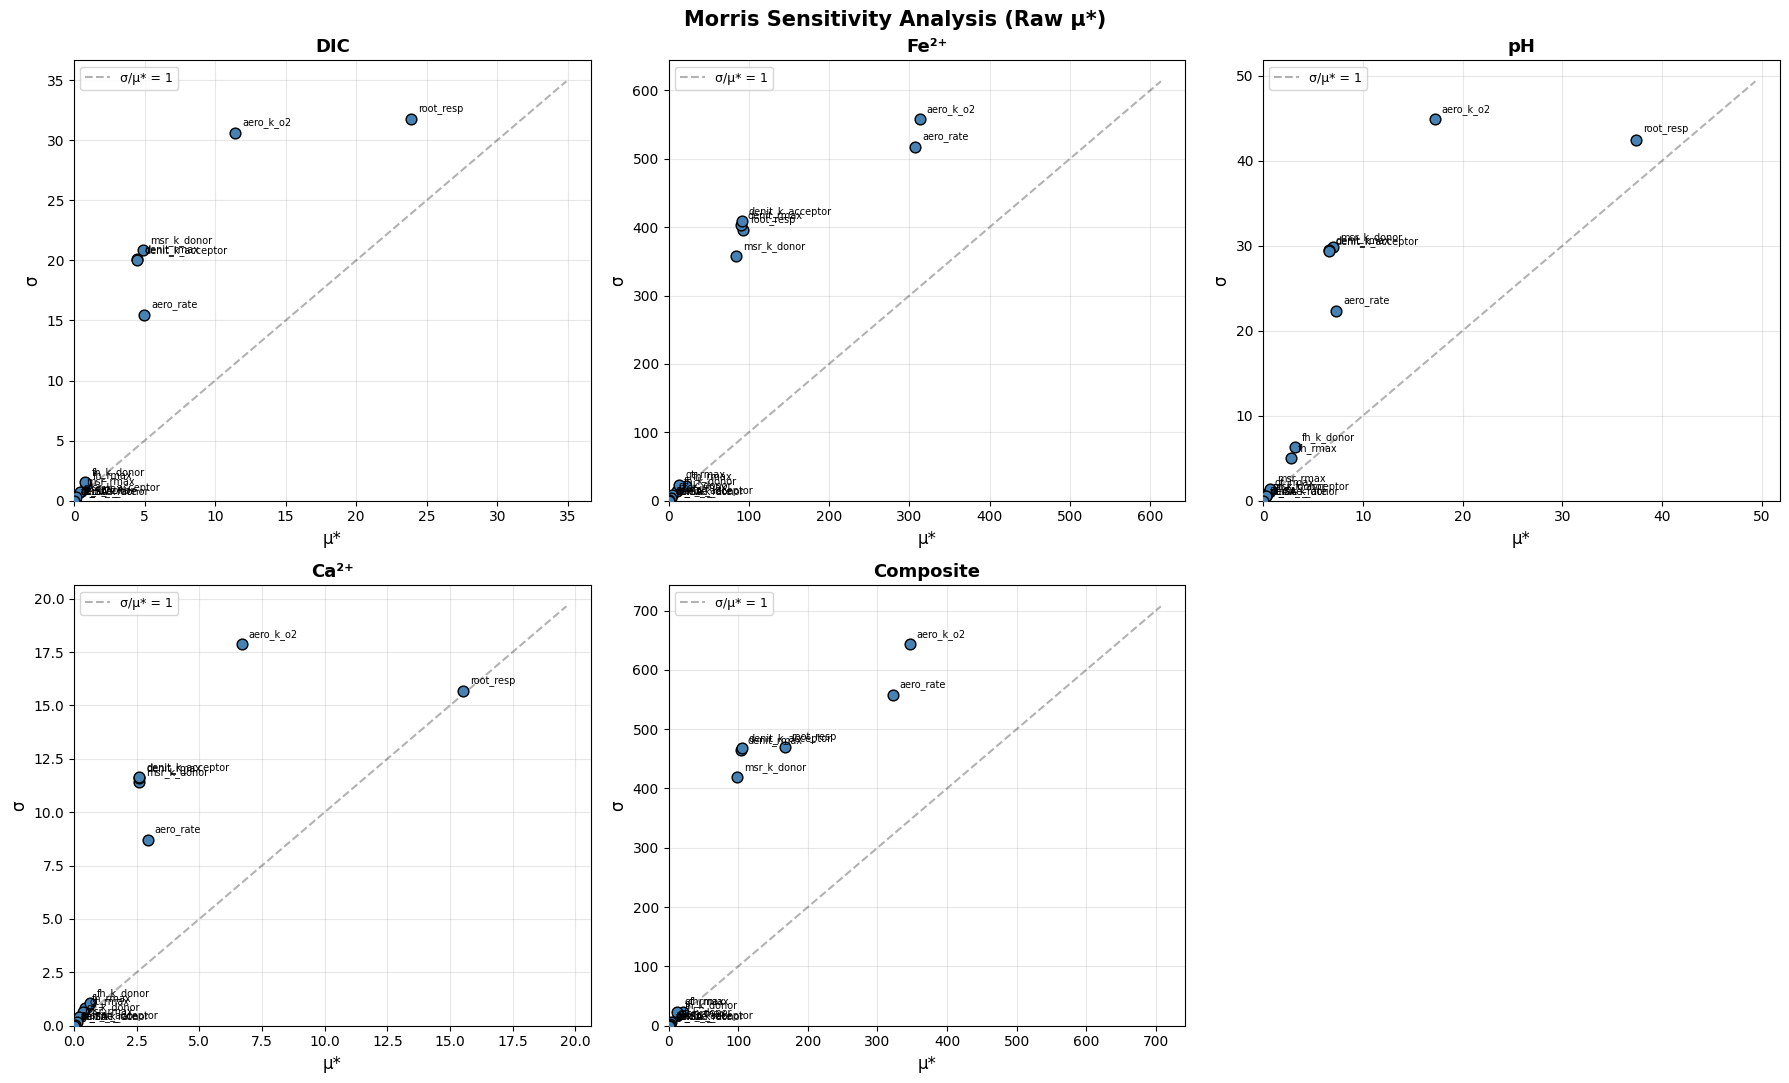

In [19]:
# ============================================================
# Plot mu*-sigma: RAW
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Morris Sensitivity Analysis (Raw μ*)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, (col, label) in enumerate(OBJ_COLUMNS.items()):
    if col not in results:
        continue

    ax = axes[idx]
    si = results[col]

    mu_star = si['mu_star']
    sigma = si['sigma']

    ax.scatter(mu_star, sigma, s=60, c='steelblue', edgecolors='black', zorder=3)

    for i, name in enumerate(problem['names']):
        ax.annotate(name, (mu_star[i], sigma[i]),
                     textcoords="offset points", xytext=(5, 5),
                     fontsize=7, ha='left')

    max_val = max(max(mu_star), max(sigma)) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='σ/μ* = 1')

    ax.set_xlabel('μ*', fontsize=12)
    ax.set_ylabel('σ', fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "morris_mu_sigma_raw.png", dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / "morris_mu_sigma_raw.pdf", bbox_inches='tight')


Plots saved to /Users/christiandewey/Code/dewey-etal_meanders/sensitivity/analysis_results


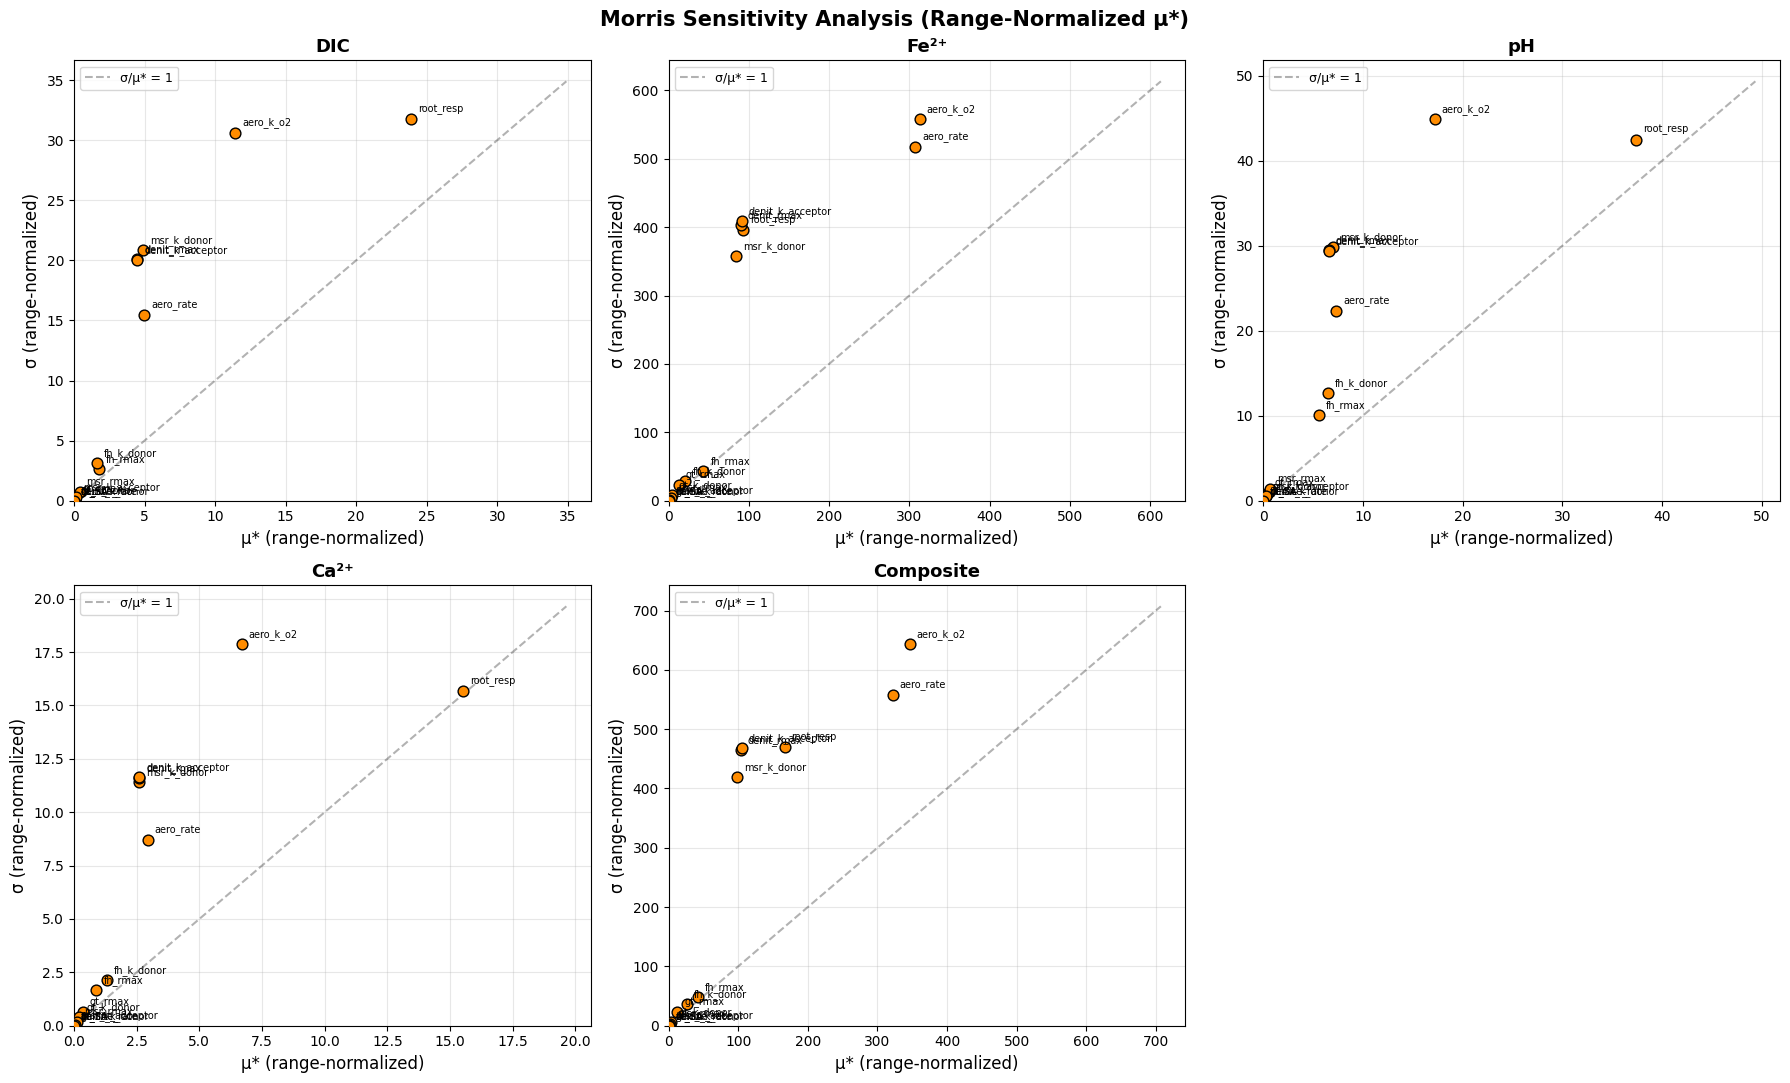

In [20]:
# ============================================================
# Plot mu*-sigma: RANGE-NORMALIZED
# ============================================================
param_ranges = np.array([b[1] - b[0] for b in problem['bounds']])
max_range = param_ranges.max()
norm_factors = max_range / param_ranges

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Morris Sensitivity Analysis (Range-Normalized μ*)', fontsize=15, fontweight='bold')
axes = axes.flatten()

for idx, (col, label) in enumerate(OBJ_COLUMNS.items()):
    if col not in results:
        continue

    ax = axes[idx]
    si = results[col]

    mu_star = si['mu_star'] * norm_factors
    sigma = si['sigma'] * norm_factors

    ax.scatter(mu_star, sigma, s=60, c='darkorange', edgecolors='black', zorder=3)

    for i, name in enumerate(problem['names']):
        ax.annotate(name, (mu_star[i], sigma[i]),
                     textcoords="offset points", xytext=(5, 5),
                     fontsize=7, ha='left')

    max_val = max(max(mu_star), max(sigma)) * 1.1
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='σ/μ* = 1')

    ax.set_xlabel('μ* (range-normalized)', fontsize=12)
    ax.set_ylabel('σ (range-normalized)', fontsize=12)
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(left=0)
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

axes[5].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "morris_mu_sigma_normalized.png", dpi=200, bbox_inches='tight')
plt.savefig(OUTPUT_DIR / "morris_mu_sigma_normalized.pdf", bbox_inches='tight')

print(f"\nPlots saved to {OUTPUT_DIR}")


In [23]:
# ============================================================
# Summary: parameter ranking across all objective functions
# ============================================================
print(f"\n{'=' * 80}")
print("PARAMETER RANKING BY μ* ACROSS ALL OBJECTIVE FUNCTIONS")
print(f"{'=' * 80}")

ranking_df = pd.DataFrame({'parameter': problem['names']})
ranking_norm_df = pd.DataFrame({'parameter': problem['names']})

param_ranges = np.array([b[1] - b[0] for b in problem['bounds']])
max_range = param_ranges.max()
norm_factors = max_range / param_ranges

for col, label in OBJ_COLUMNS.items():
    if col not in results:
        continue
    si = results[col]
    # Raw ranking
    ranks = np.argsort(np.argsort(-si['mu_star'])) + 1
    ranking_df[label] = ranks
    # Normalized ranking
    mu_star_norm = si['mu_star'] * norm_factors
    ranks_norm = np.argsort(np.argsort(-mu_star_norm)) + 1
    ranking_norm_df[label] = ranks_norm

# Raw rankings
ranking_df['mean_rank'] = ranking_df[list(OBJ_COLUMNS.values())].mean(axis=1)
ranking_df = ranking_df.sort_values('mean_rank')

print(f"\n{'Parameter':<22}", end="")
for label in OBJ_COLUMNS.values():
    print(f"{label:>12}", end="")
print(f"{'Mean Rank':>12}")
print("-" * (22 + 12 * (len(OBJ_COLUMNS) + 1)))
for _, row in ranking_df.iterrows():
    print(f"{row['parameter']:<22}", end="")
    for label in OBJ_COLUMNS.values():
        print(f"{int(row[label]):>12}", end="")
    print(f"{row['mean_rank']:>12.1f}")

ranking_df.to_csv(OUTPUT_DIR / "morris_parameter_rankings_raw.csv", index=False)

# Normalized rankings
ranking_norm_df['mean_rank'] = ranking_norm_df[list(OBJ_COLUMNS.values())].mean(axis=1)
ranking_norm_df = ranking_norm_df.sort_values('mean_rank')

print(f"\n{'=' * 80}")
print("PARAMETER RANKING BY RANGE-NORMALIZED μ*")
print(f"{'=' * 80}")

print(f"\n{'Parameter':<22}", end="")
for label in OBJ_COLUMNS.values():
    print(f"{label:>12}", end="")
print(f"{'Mean Rank':>12}")
print("-" * (22 + 12 * (len(OBJ_COLUMNS) + 1)))
for _, row in ranking_norm_df.iterrows():
    print(f"{row['parameter']:<22}", end="")
    for label in OBJ_COLUMNS.values():
        print(f"{int(row[label]):>12}", end="")
    print(f"{row['mean_rank']:>12.1f}")

ranking_norm_df.to_csv(OUTPUT_DIR / "morris_parameter_rankings_normalized.csv", index=False)
print(f"\nRankings saved to {OUTPUT_DIR}")


PARAMETER RANKING BY μ* ACROSS ALL OBJECTIVE FUNCTIONS

Parameter                      DIC        Fe²⁺          pH        Ca²⁺   Composite   Mean Rank
----------------------------------------------------------------------------------------------
aero_k_o2                        2           1           2           2           1         1.6
root_resp                        1           3           1           1           3         1.8
aero_rate                        3           2           3           3           2         2.6
denit_k_acceptor                 6           4           6           4           4         4.8
msr_k_donor                      4           6           4           5           6         5.0
denit_rmax                       5           5           5           6           5         5.2
fh_rmax                          7           7           8           8           7         7.4
fh_k_donor                       8           9           7           7           8      

In [24]:
# ============================================================
# Identify negligible parameters
# ============================================================
print(f"\n{'=' * 60}")
print("NEGLIGIBLE PARAMETERS (μ* < 10% of max μ*)")
print(f"{'=' * 60}")

print("\n--- Raw μ* ---")
all_negligible_raw = set(problem['names'])
for col, label in OBJ_COLUMNS.items():
    if col not in results:
        continue
    si = results[col]
    threshold = 0.10 * max(si['mu_star'])
    negligible = [name for name, ms in zip(problem['names'], si['mu_star']) if ms < threshold]
    important = {name for name, ms in zip(problem['names'], si['mu_star']) if ms >= threshold}
    all_negligible_raw -= important
    print(f"  {label}: {', '.join(negligible) if negligible else 'none'}")

print(f"\n  Safe to fix (negligible across ALL objectives, raw):")
if all_negligible_raw:
    for p in sorted(all_negligible_raw):
        print(f"    - {p}")
else:
    print("    None")

print("\n--- Range-Normalized μ* ---")
all_negligible_norm = set(problem['names'])
for col, label in OBJ_COLUMNS.items():
    if col not in results:
        continue
    si = results[col]
    mu_star_norm = si['mu_star'] * norm_factors
    threshold = 0.10 * max(mu_star_norm)
    negligible = [name for name, ms in zip(problem['names'], mu_star_norm) if ms < threshold]
    important = {name for name, ms in zip(problem['names'], mu_star_norm) if ms >= threshold}
    all_negligible_norm -= important
    print(f"  {label}: {', '.join(negligible) if negligible else 'none'}")

print(f"\n  Safe to fix (negligible across ALL objectives, normalized):")
if all_negligible_norm:
    for p in sorted(all_negligible_norm):
        print(f"    - {p}")
else:
    print("    None")


NEGLIGIBLE PARAMETERS (μ* < 10% of max μ*)

--- Raw μ* ---
  DIC: calcite_rate, fh_rmax, fh_k_donor, fh_SA, gt_rmax, gt_k_donor, gt_SA, msr_rmax, msr_k_acceptor, denit_k_donor
  Fe²⁺: calcite_rate, fh_rmax, fh_k_donor, fh_SA, gt_rmax, gt_k_donor, gt_SA, msr_rmax, msr_k_acceptor, denit_k_donor
  pH: calcite_rate, fh_rmax, fh_k_donor, fh_SA, gt_rmax, gt_k_donor, gt_SA, msr_rmax, msr_k_acceptor, denit_k_donor
  Ca²⁺: calcite_rate, fh_rmax, fh_k_donor, fh_SA, gt_rmax, gt_k_donor, gt_SA, msr_rmax, msr_k_acceptor, denit_k_donor
  Composite: calcite_rate, fh_rmax, fh_k_donor, fh_SA, gt_rmax, gt_k_donor, gt_SA, msr_rmax, msr_k_acceptor, denit_k_donor

  Safe to fix (negligible across ALL objectives, raw):
    - calcite_rate
    - denit_k_donor
    - fh_SA
    - fh_k_donor
    - fh_rmax
    - gt_SA
    - gt_k_donor
    - gt_rmax
    - msr_k_acceptor
    - msr_rmax

--- Range-Normalized μ* ---
  DIC: calcite_rate, fh_rmax, fh_k_donor, fh_SA, gt_rmax, gt_k_donor, gt_SA, msr_rmax, msr_k_acceptor,